In [1]:
import pandas as pd

In [2]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="phamquiluan/RCAEval",
    repo_type="dataset",
    allow_patterns="re2ob_productcatalogservice_cpu_1/*",
    local_dir="/content/data"
)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

'/content/data'

In [3]:
cases = pd.read_parquet(
    "hf://datasets/phamquiluan/RCAEval/cases.parquet"
)

print(cases.shape)
print(cases.columns.tolist())

(735, 22)
['case', 'dataset', 'suite', 'system', 'system_name', 'root_cause_service', 'fault', 'fault_description', 'repetition', 'inject_time', 'n_metrics', 'n_timesteps', 'time_start', 'time_end', 'duration_minutes', 'normal_timesteps', 'faulty_timesteps', 'has_logs', 'n_logs', 'has_traces', 'n_traces', 'has_root_cause_file']


In [4]:
case = cases[
    cases["dataset"].str.contains("RE2", case=False, na=False)
].iloc[0]

print(case)

case                   re2ob_checkoutservice_cpu_1
dataset                                     RE2-OB
suite                                          RE2
system                                          ob
system_name                        Online Boutique
root_cause_service                 checkoutservice
fault                                          cpu
fault_description                       CPU stress
repetition                                       1
inject_time                             1705354566
n_metrics                                       72
n_timesteps                                   1441
time_start                              1705353846
time_end                                1705355286
duration_minutes                              24.0
normal_timesteps                               720
faulty_timesteps                               721
has_logs                                      True
n_logs                                      171322
has_traces                     

In [5]:
import os

for root, dirs, files in os.walk("/content/data"):
    for file in files:
        print(os.path.join(root, file))

/content/data/re2ob_productcatalogservice_cpu_1/metrics.parquet
/content/data/re2ob_productcatalogservice_cpu_1/inject_time.txt
/content/data/re2ob_productcatalogservice_cpu_1/logs.parquet
/content/data/re2ob_productcatalogservice_cpu_1/traces.parquet
/content/data/.cache/huggingface/CACHEDIR.TAG
/content/data/.cache/huggingface/.gitignore
/content/data/.cache/huggingface/trees/afeacb11bcc94dadfd1c8f483ee4377b2b8b614e.json
/content/data/.cache/huggingface/download/re2ob_productcatalogservice_cpu_1/inject_time.txt.metadata
/content/data/.cache/huggingface/download/re2ob_productcatalogservice_cpu_1/logs.parquet.lock
/content/data/.cache/huggingface/download/re2ob_productcatalogservice_cpu_1/metrics.parquet.lock
/content/data/.cache/huggingface/download/re2ob_productcatalogservice_cpu_1/traces.parquet.lock
/content/data/.cache/huggingface/download/re2ob_productcatalogservice_cpu_1/inject_time.txt.lock
/content/data/.cache/huggingface/download/re2ob_productcatalogservice_cpu_1/traces.parqu

In [6]:
import pandas as pd

case_path = "/content/data/re2ob_productcatalogservice_cpu_1"

metrics = pd.read_parquet(f"{case_path}/metrics.parquet")
logs = pd.read_parquet(f"{case_path}/logs.parquet")
traces = pd.read_parquet(f"{case_path}/traces.parquet")

with open(f"{case_path}/inject_time.txt") as f:
    inject_time = f.read().strip()

print("Inject time:", inject_time)

print("\nMetrics:")
print(metrics.shape)
print(metrics.head())

print("\nLogs:")
print(logs.shape)
print(logs.head())

print("\nTraces:")
print(traces.shape)
print(traces.head())

Inject time: 1705340542

Metrics:
(1441, 72)
         time  adservice_cpu  cartservice_cpu  checkoutservice_cpu  \
0  1705339822       0.339336         1.161912             0.230925   
1  1705339823       0.409095         1.161912             0.230925   
2  1705339824       0.418377         1.161912             0.230925   
3  1705339825       0.427658         1.161912             0.230925   
4  1705339826       0.436939         1.161912             0.230925   

   currencyservice_cpu  emailservice_cpu  frontend_cpu  paymentservice_cpu  \
0            14.675869          0.227218      3.831110            0.220750   
1            14.784304          0.227218      3.751525            0.208349   
2            14.784304          0.229870      3.671940            0.245528   
3            14.784304          0.229870      3.592355            0.245528   
4            12.224896          0.229870      3.512769            0.245528   

   productcatalogservice_cpu  recommendationservice_cpu  ...  \
0

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
metrics["time"] = pd.to_datetime(metrics["time"],unit="s")
inject_time = pd.to_datetime(int(inject_time), unit="s")

delta = pd.Timedelta(seconds=120)
window = metrics[(metrics["time"] >= inject_time - delta) & (metrics["time"] <= inject_time + delta)]

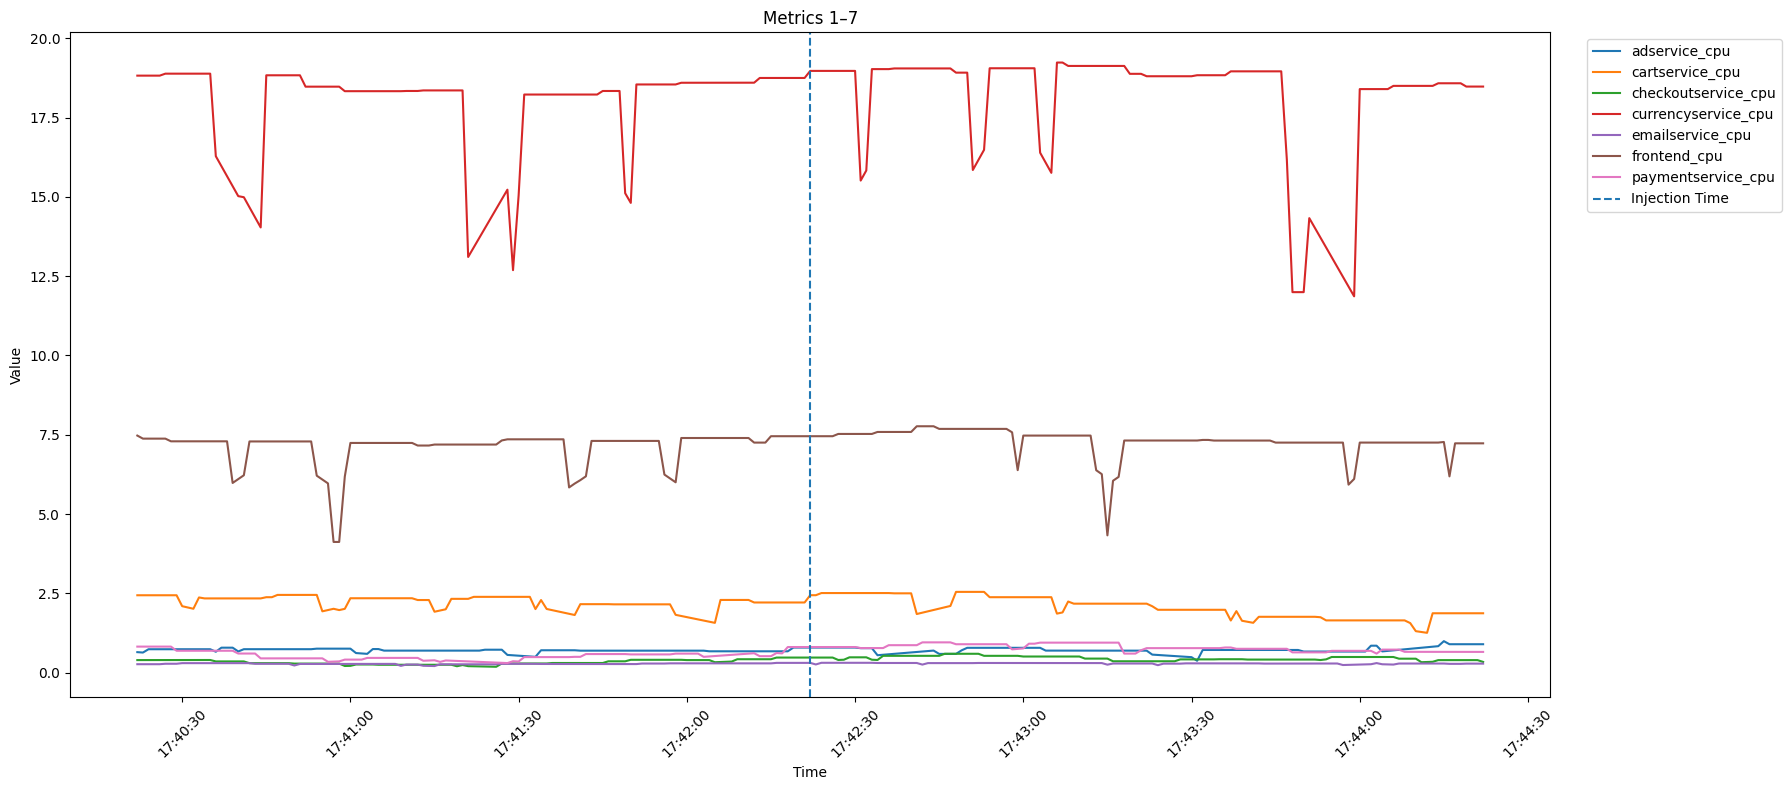

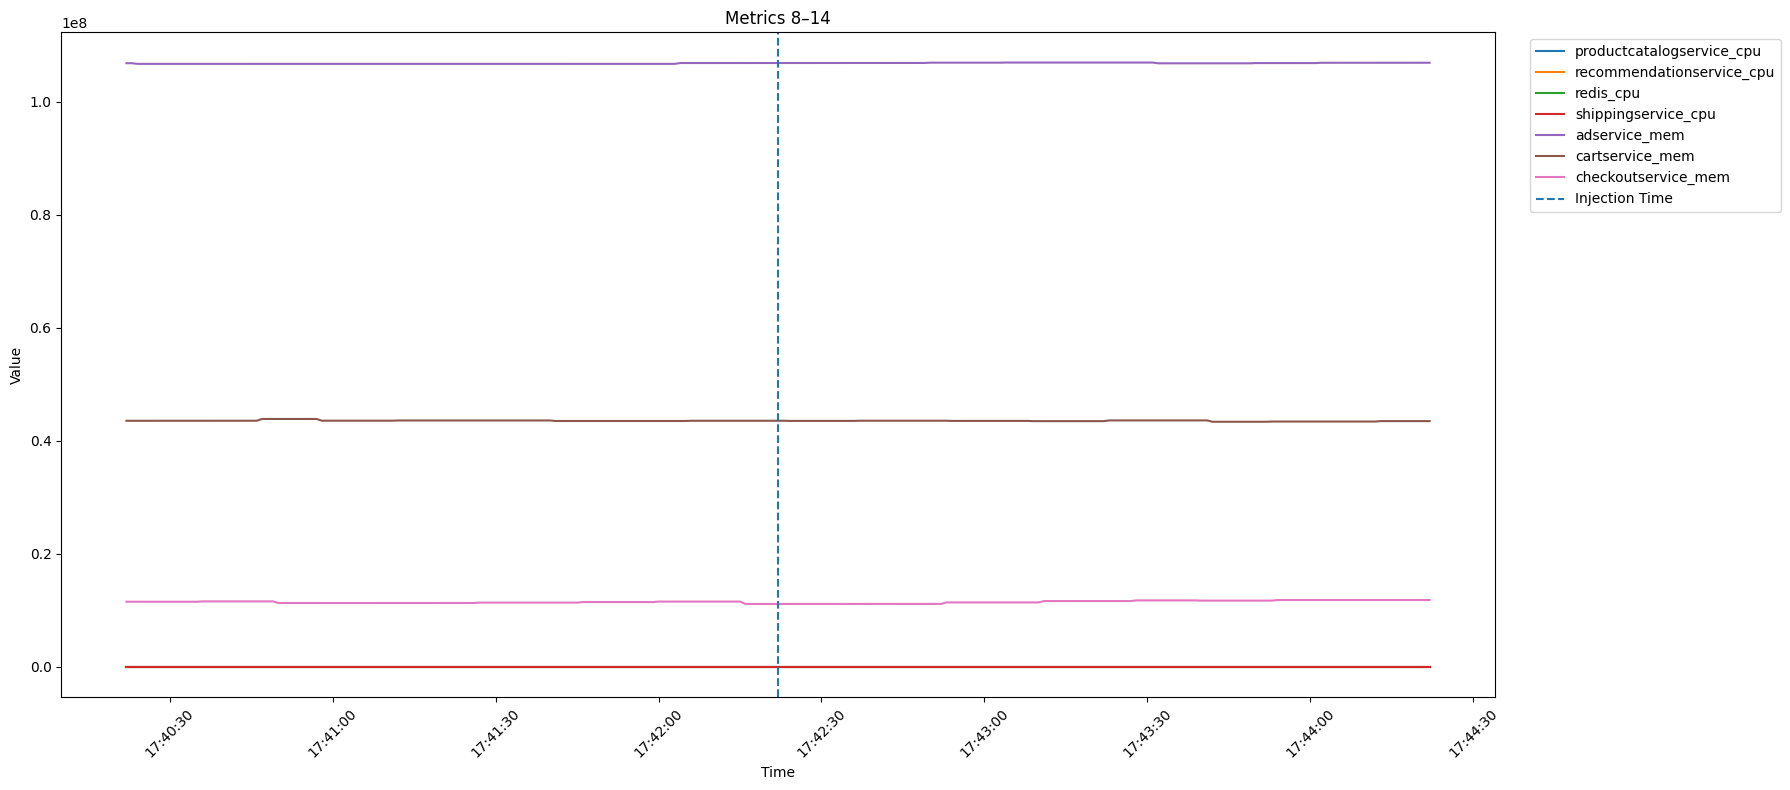

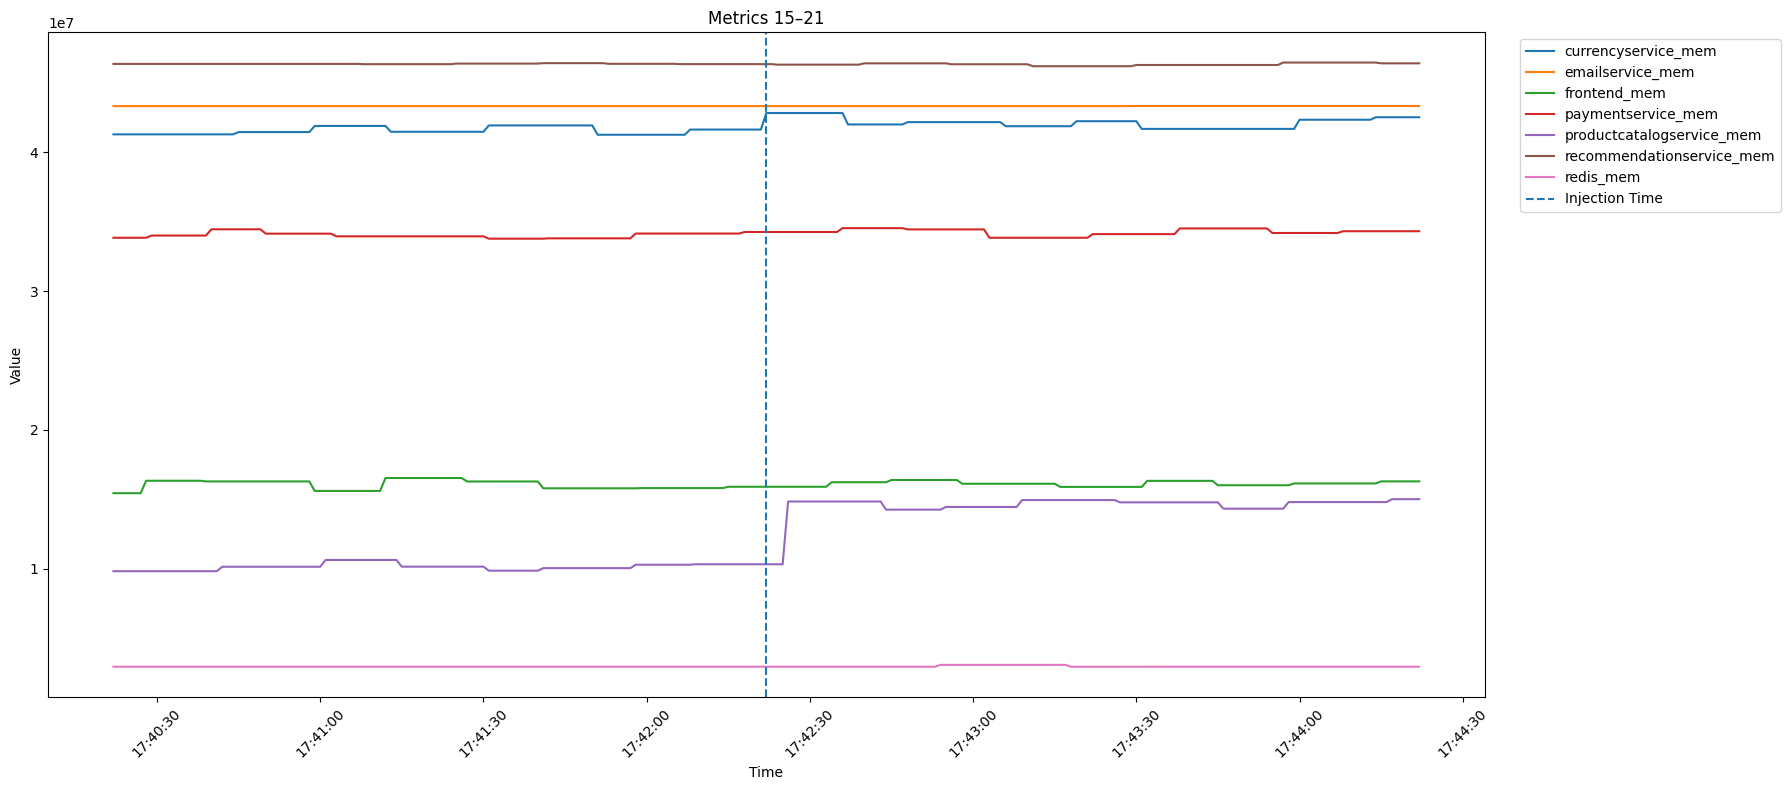

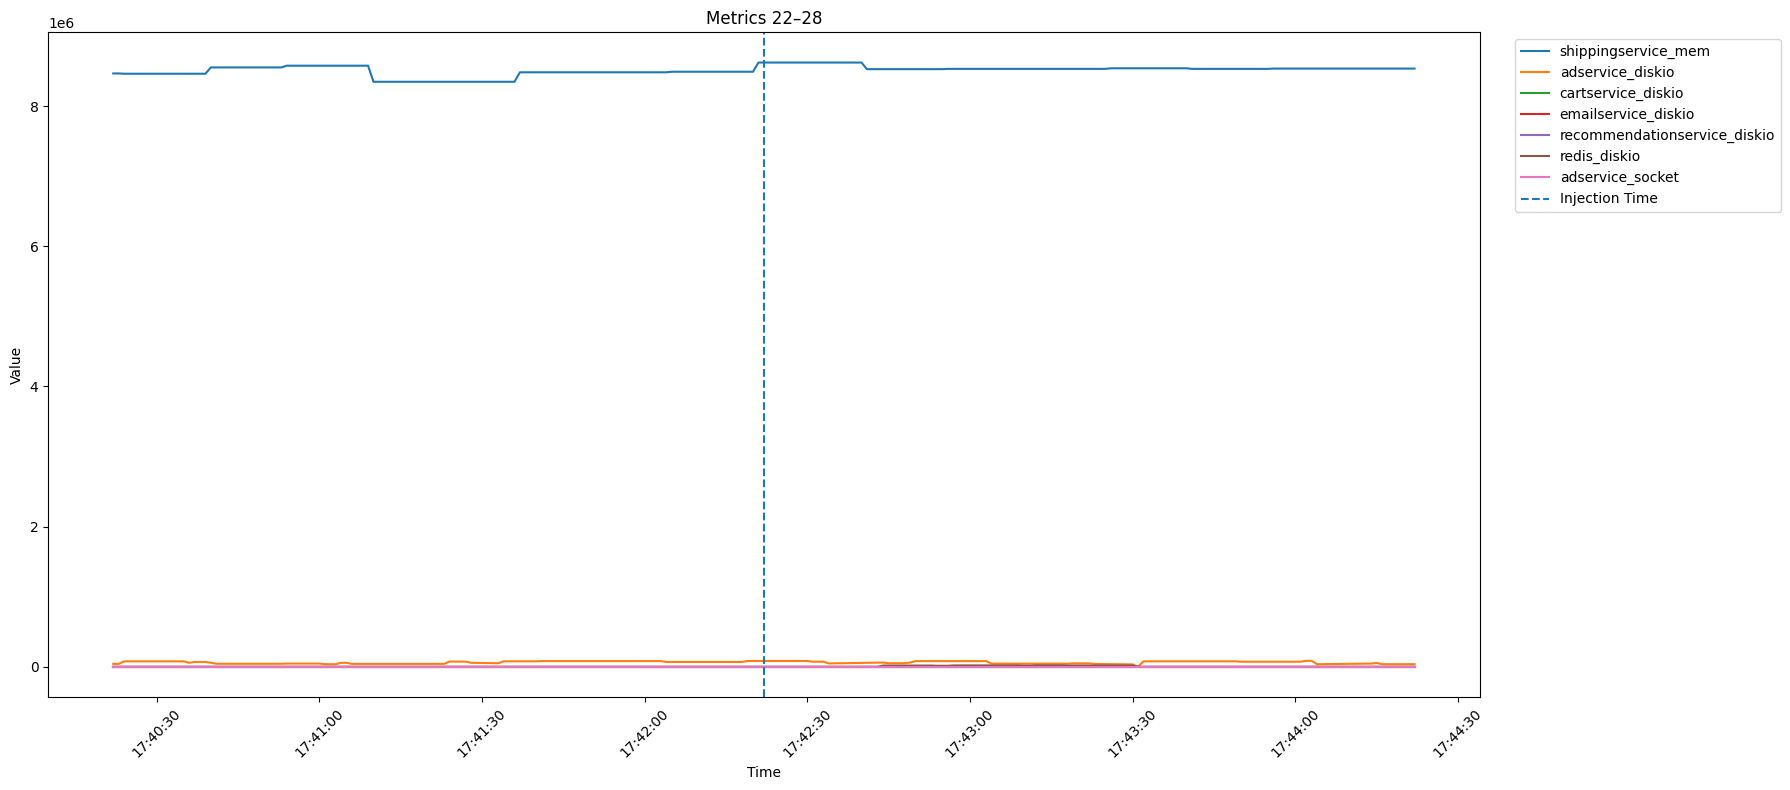

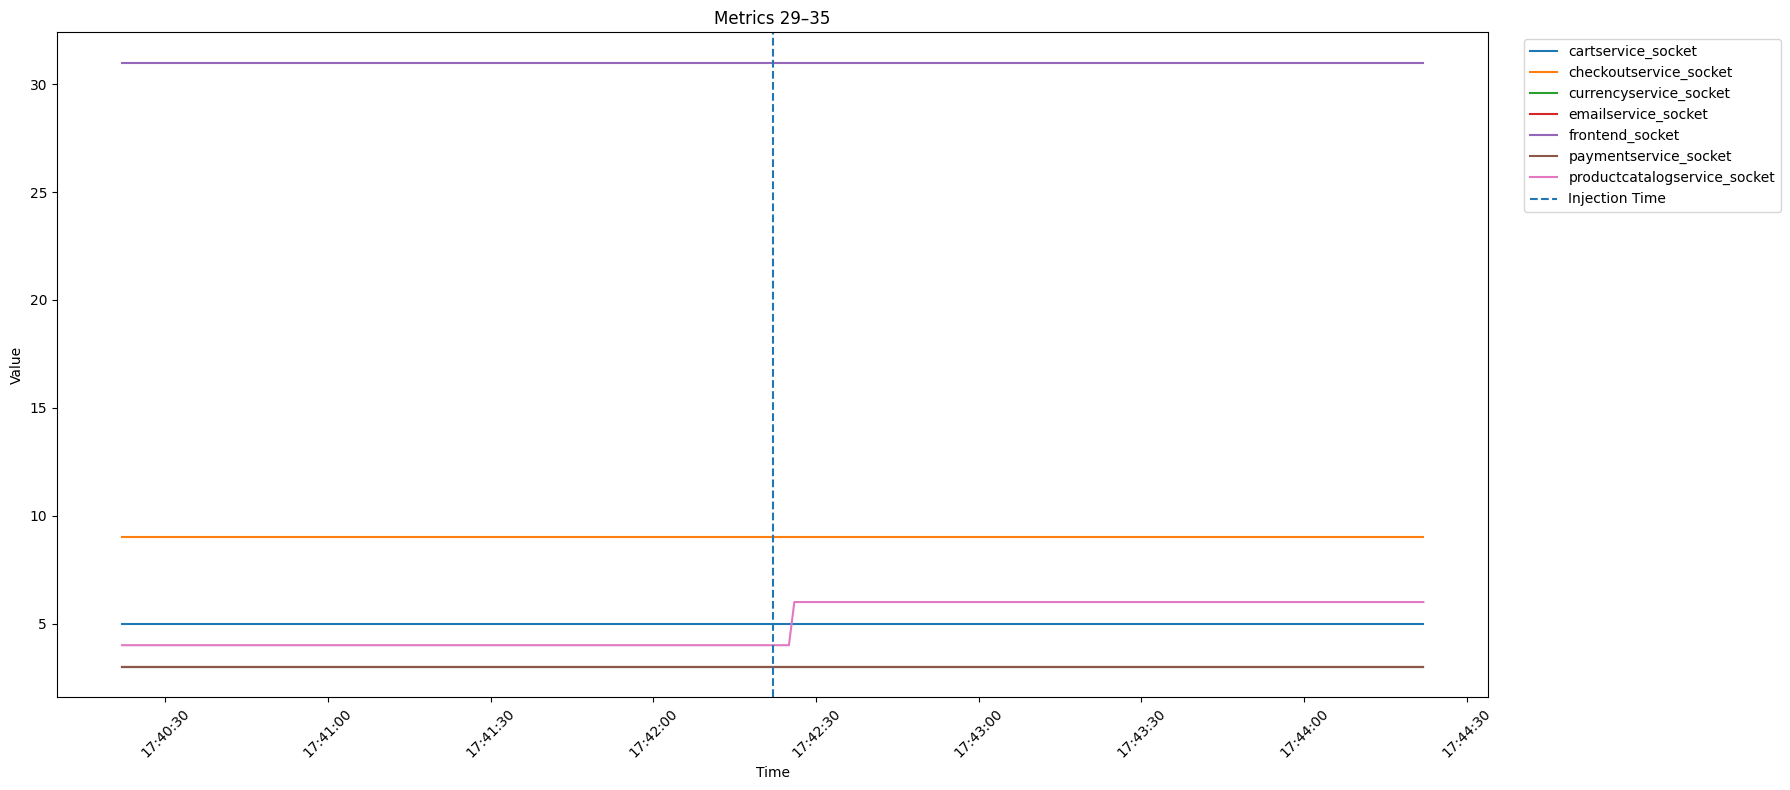

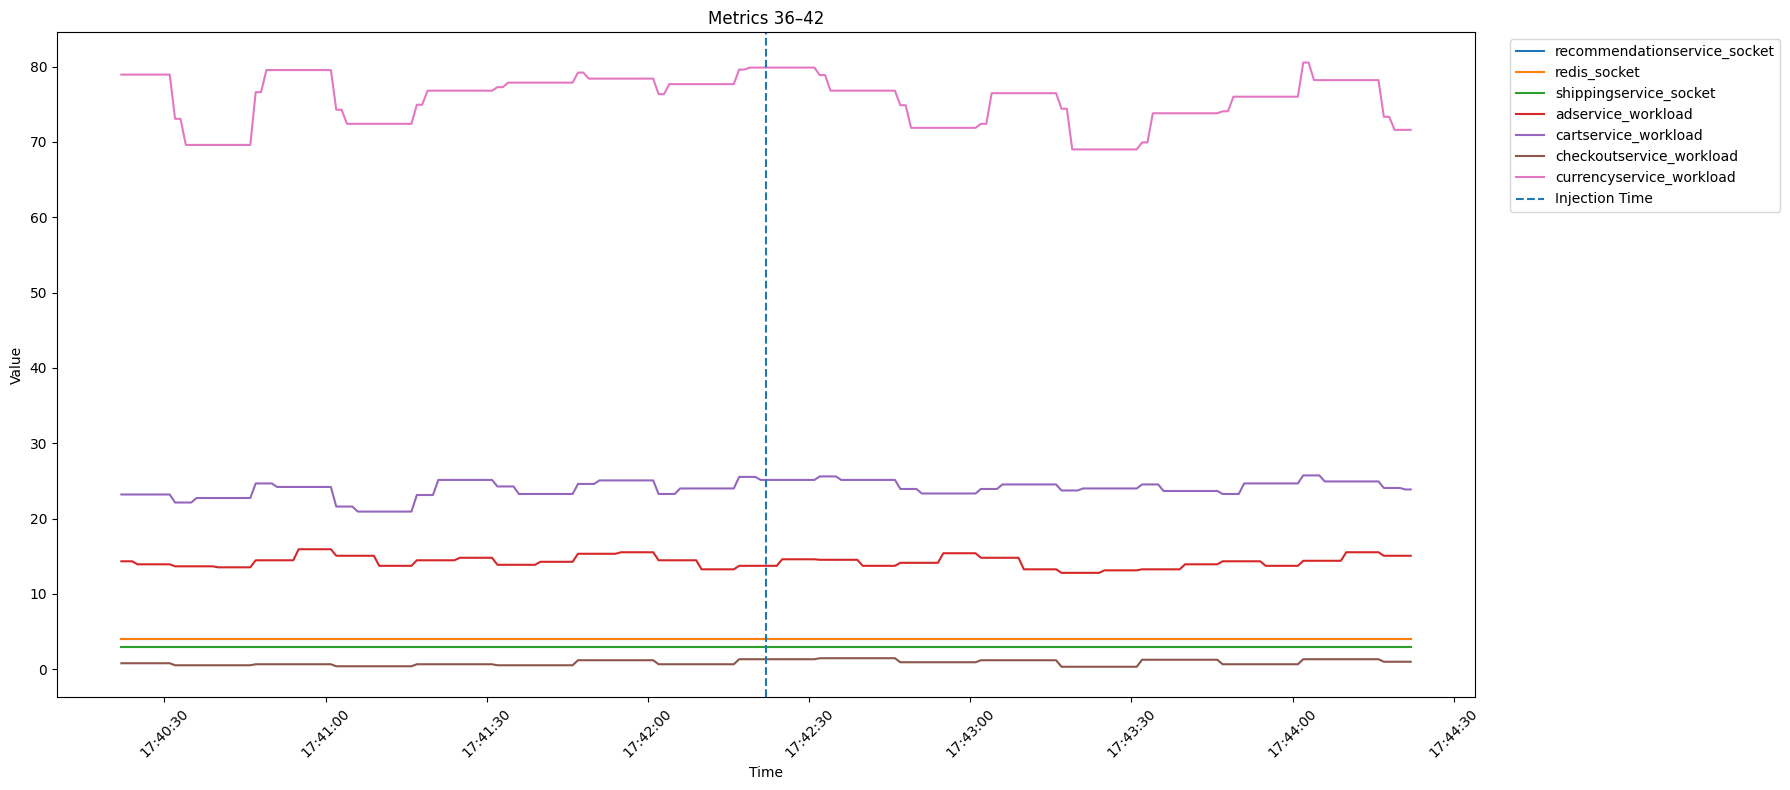

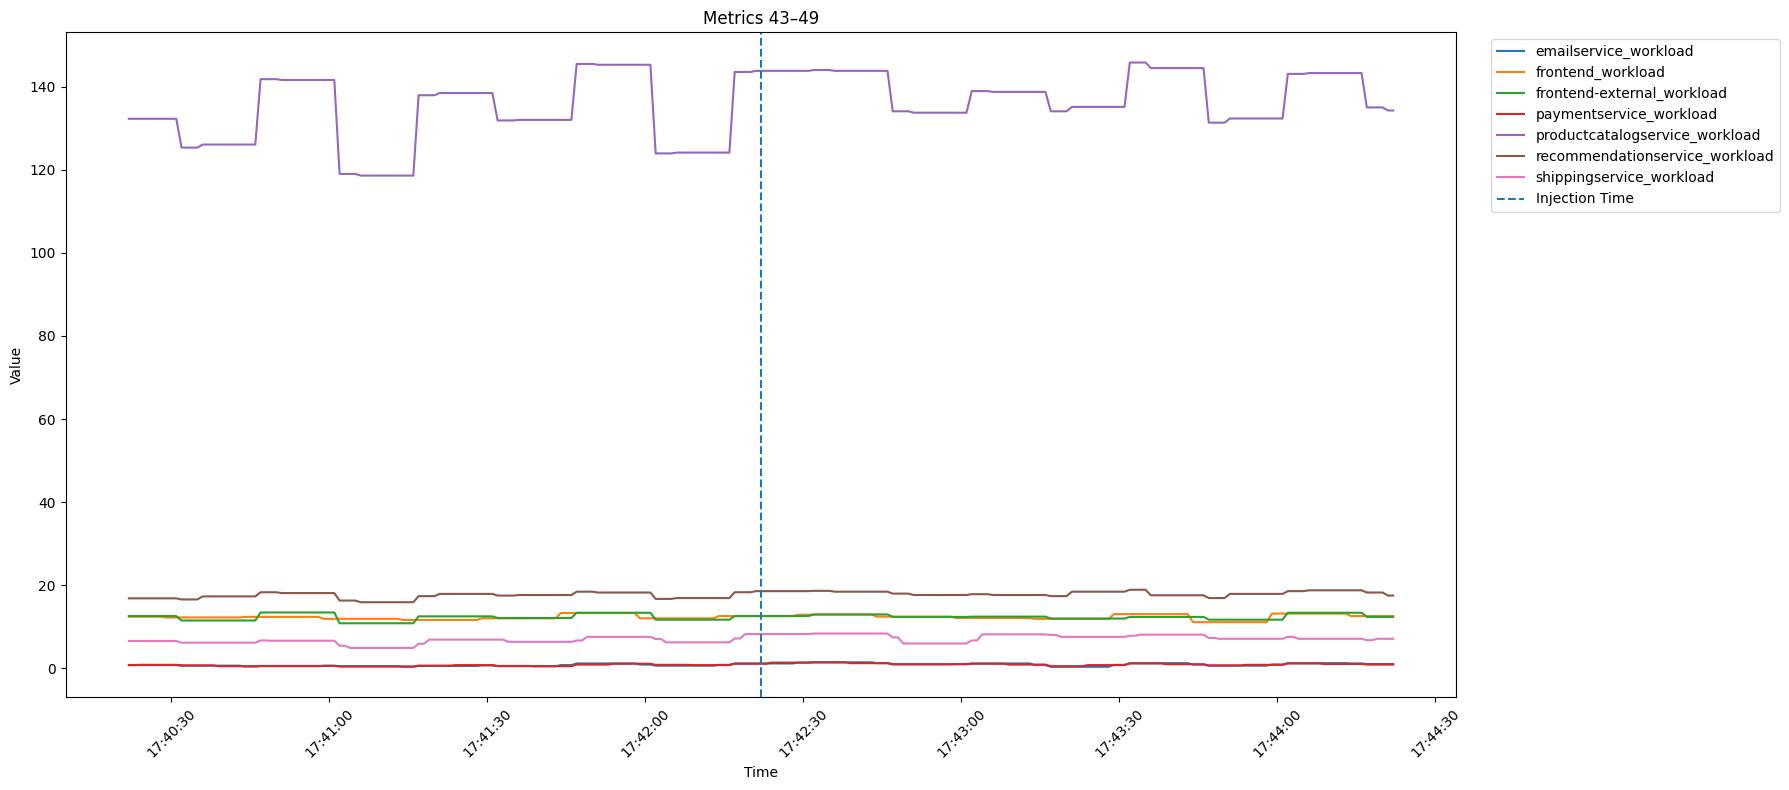

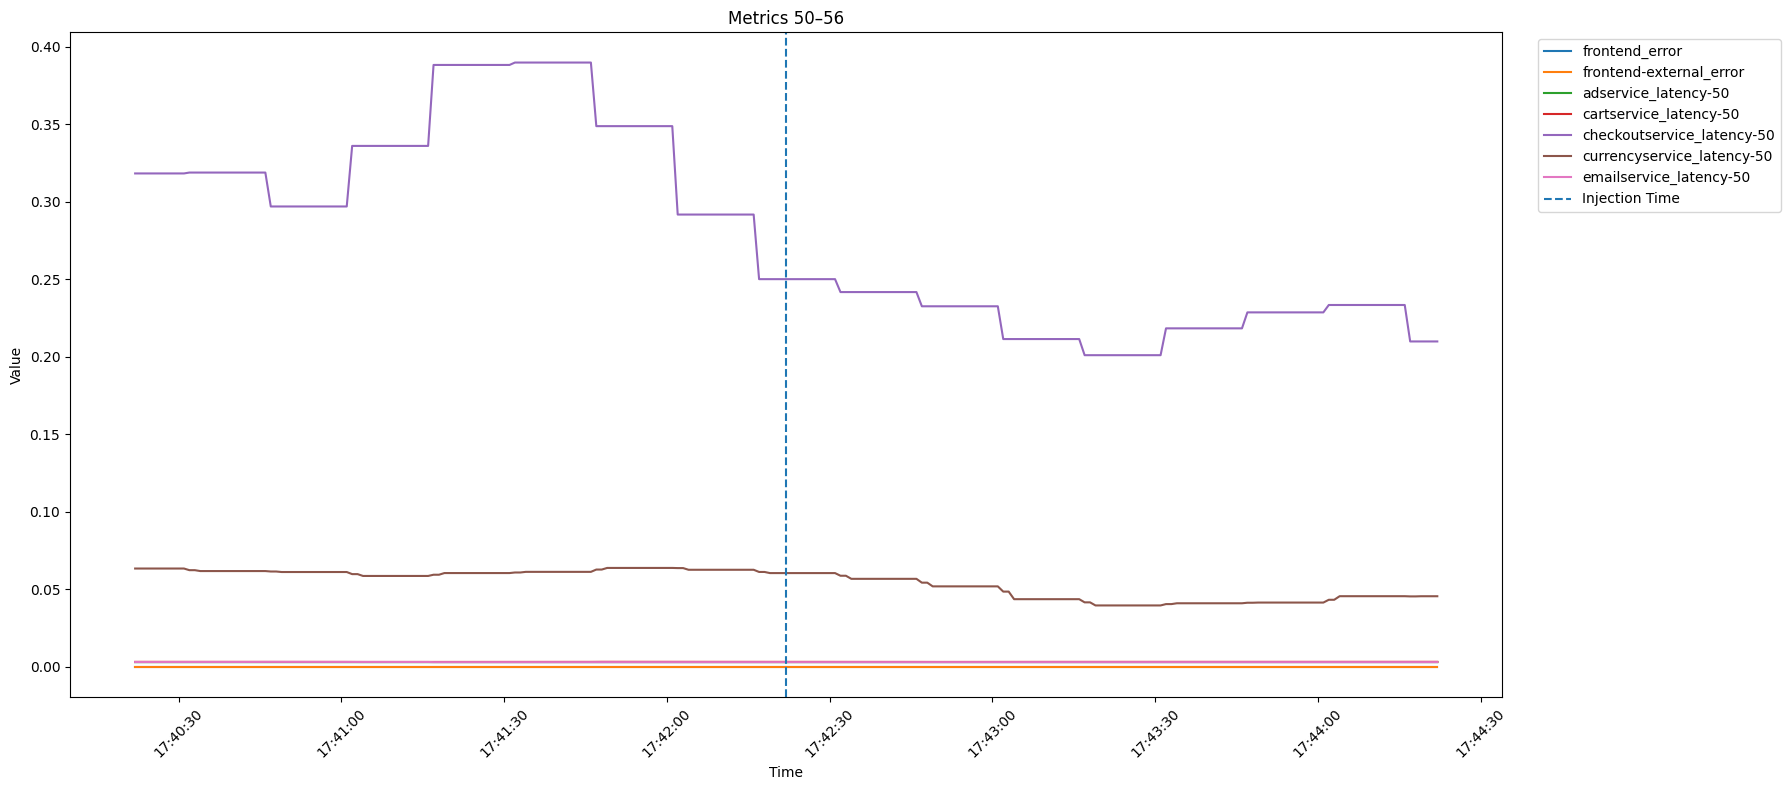

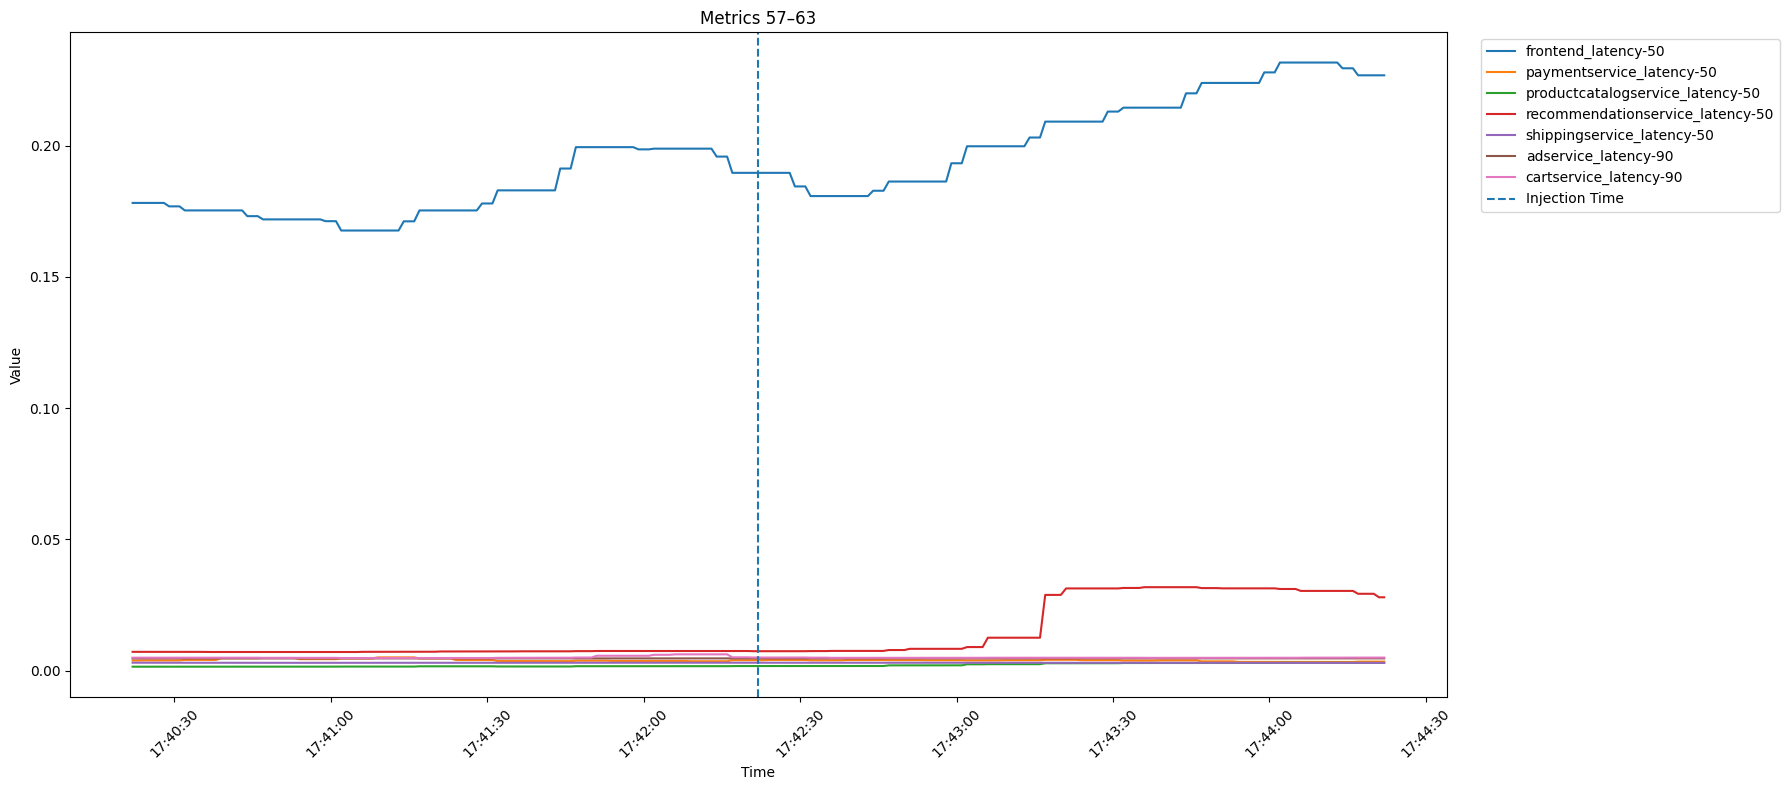

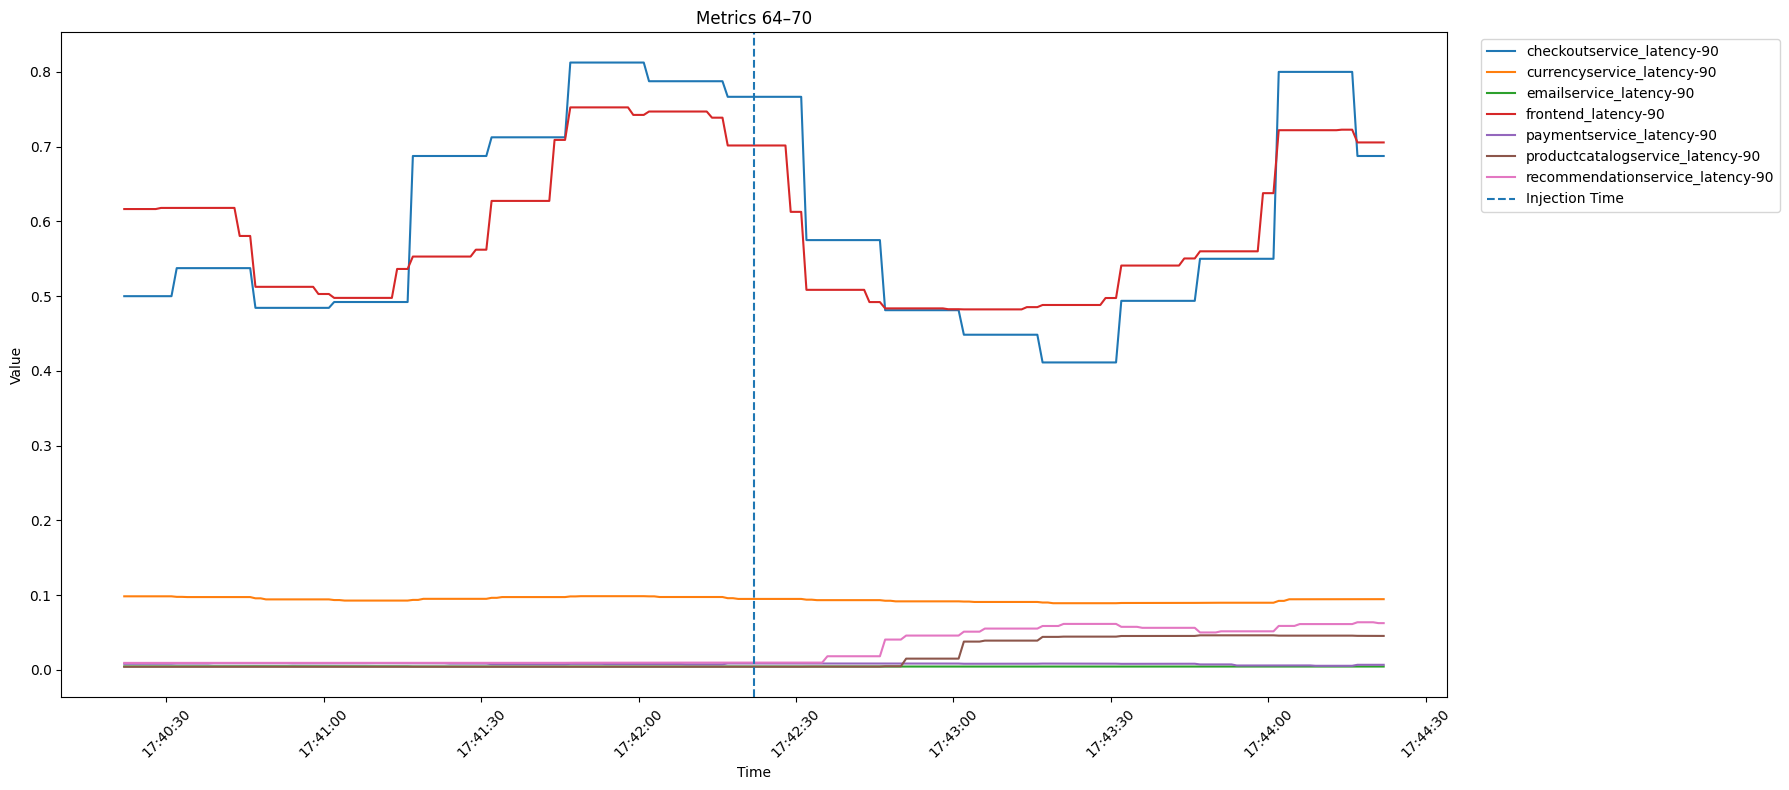

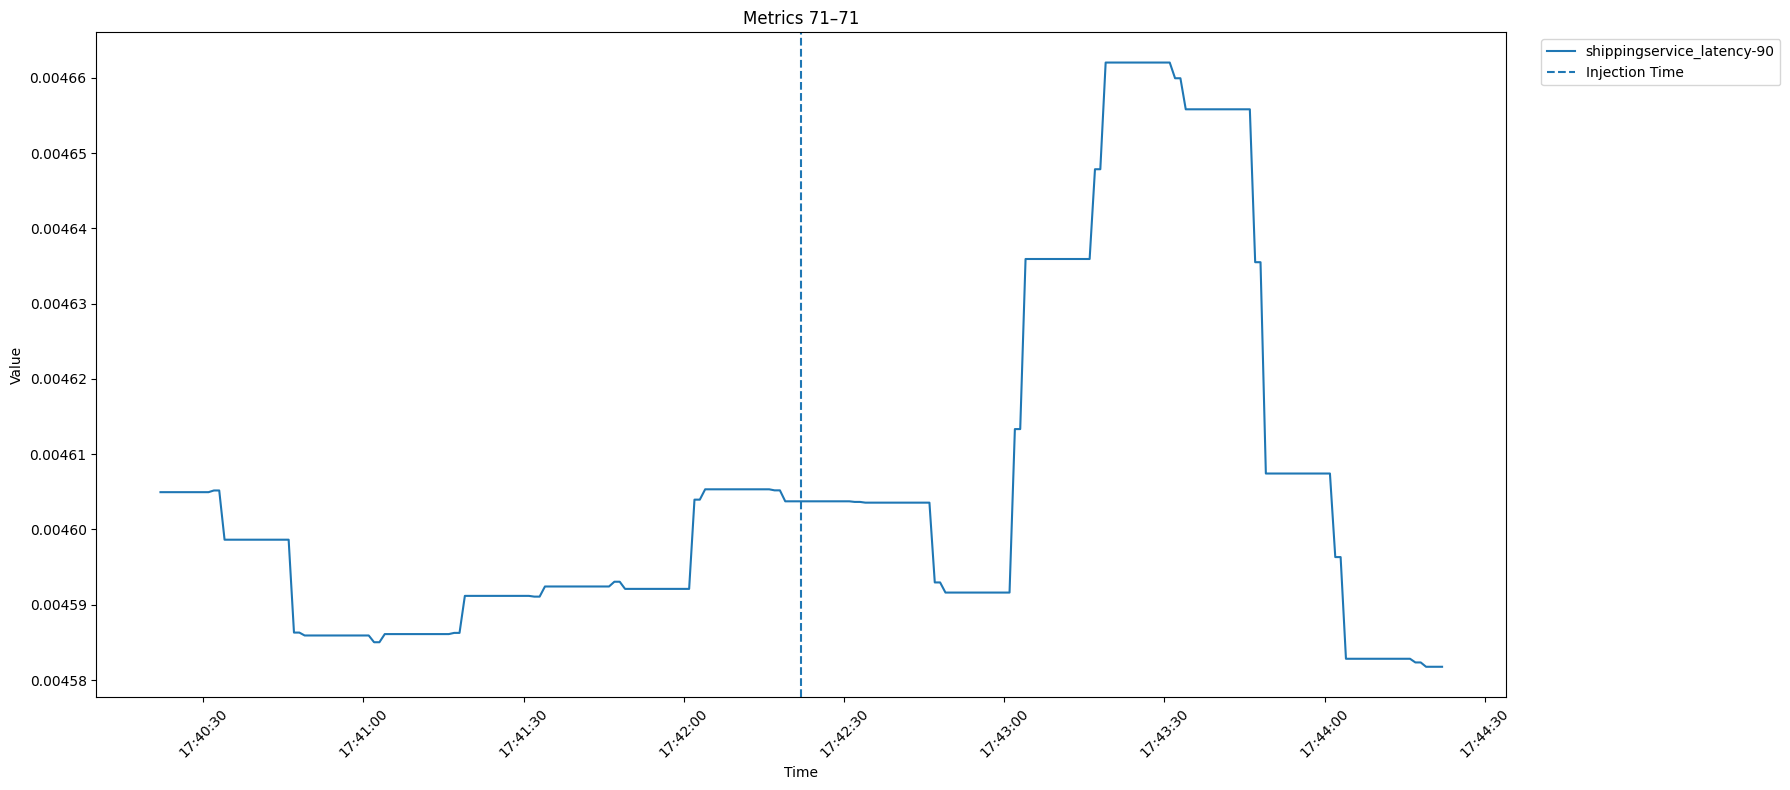

In [9]:
metric_cols = [col for col in window.columns if col != "time"]

for start in range(0, len(metric_cols), 7):

    cols = metric_cols[start:start + 7]

    plt.figure(figsize=(18, 8))

    for col in cols:
        sns.lineplot(
            x=window["time"],
            y=window[col],
            label=col
        )

    plt.axvline(
        inject_time,
        linestyle="--",
        label="Injection Time"
    )

    plt.title(f"Metrics {start + 1}–{start + len(cols)}")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.xticks(rotation=45)

    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

In [10]:
print("METRICS")
print(metrics.shape)
print(metrics.columns.tolist())

print("\nLOGS")
print(logs.shape)
print(logs.columns.tolist())

print("\nTRACES")
print(traces.shape)
print(traces.columns.tolist())

METRICS
(1441, 72)
['time', 'adservice_cpu', 'cartservice_cpu', 'checkoutservice_cpu', 'currencyservice_cpu', 'emailservice_cpu', 'frontend_cpu', 'paymentservice_cpu', 'productcatalogservice_cpu', 'recommendationservice_cpu', 'redis_cpu', 'shippingservice_cpu', 'adservice_mem', 'cartservice_mem', 'checkoutservice_mem', 'currencyservice_mem', 'emailservice_mem', 'frontend_mem', 'paymentservice_mem', 'productcatalogservice_mem', 'recommendationservice_mem', 'redis_mem', 'shippingservice_mem', 'adservice_diskio', 'cartservice_diskio', 'emailservice_diskio', 'recommendationservice_diskio', 'redis_diskio', 'adservice_socket', 'cartservice_socket', 'checkoutservice_socket', 'currencyservice_socket', 'emailservice_socket', 'frontend_socket', 'paymentservice_socket', 'productcatalogservice_socket', 'recommendationservice_socket', 'redis_socket', 'shippingservice_socket', 'adservice_workload', 'cartservice_workload', 'checkoutservice_workload', 'currencyservice_workload', 'emailservice_workload

In [11]:
traces.head()

,time,traceID,spanID,serviceName,methodName,operationName,parentSpanID,startTimeMillis,startTime,duration,statusCode
0,17:30,48dcdcdff17f4f2e54ece4ce20d1232d,8023c7f7db7f34c4,currencyservice,Convert,grpc.hipstershop.CurrencyService/Convert,757c47b7a3cb688c,1705339822000,1705339822000999,108,0
1,17:30,effa8a52550f057dc3733b1d1fd8eec4,270618f80f1461e6,currencyservice,Convert,grpc.hipstershop.CurrencyService/Convert,0042b74d90a913cc,1705339822001,1705339822001999,78,0
2,17:30,89d245bc23ded788d8a044ed633615ce,f1ddd1b37def7906,currencyservice,GetSupportedCurrencies,grpc.hipstershop.CurrencyService/GetSupportedC...,7a5fed9d1fc24e60,1705339822004,1705339822004999,96,0
3,17:30,e5a638b0e9e9147fd51d90749bc5beeb,b82568b9940aca84,frontendservice,GetSupportedCurrencies,hipstershop.CurrencyService/GetSupportedCurren...,7607b16e58f625b0,1705339822049,1705339822049246,158253,0
4,17:30,e5a638b0e9e9147fd51d90749bc5beeb,7607b16e58f625b0,frontendservice,<NA>,frontend,<NA>,1705339822049,1705339822049109,1161833,<NA>


In [12]:
traces["time"].head()

,time
0,17:30
1,17:30
2,17:30
3,17:30
4,17:30


In [13]:
print(traces.columns.tolist())
traces["timestamp"] = pd.to_datetime(traces["startTimeMillis"], unit="ms")


['time', 'traceID', 'spanID', 'serviceName', 'methodName', 'operationName', 'parentSpanID', 'startTimeMillis', 'startTime', 'duration', 'statusCode']


In [14]:
traces_window = traces[
    (traces["timestamp"] >= inject_time - delta) &
    (traces["timestamp"] <= inject_time + delta)
]
before_window = traces[
    (traces["timestamp"] < inject_time - delta)
]
after_window = traces[
    (traces["timestamp"] > inject_time + delta)
]

In [15]:
print(traces_window["duration"].mean(), before_window["duration"].mean(), after_window["duration"].mean())

24914.583066797884 24062.361285407493 28542.825588737836


In [16]:
service_latency = traces_window.groupby("serviceName")["duration"].agg(
    ["count", "mean", "max"]
).sort_values("mean", ascending=False)

print(service_latency)

                       count          mean      max
serviceName                                        
frontendservice        33144  44604.833152  1983850
checkoutservice         1476  44592.320461  1860699
recommendationservice   4386   14726.02736   185138
currencyservice         9151   1025.450224    93467
paymentservice           155    257.548387     4446
emailservice             203    173.684729      939
productcatalogservice  16517    120.898589   103869


In [17]:
outside_traces = traces.drop(traces_window.index)

window_service_mean = (
    traces_window.groupby("serviceName")["duration"]
    .mean()
)

outside_service_mean = (
    outside_traces.groupby("serviceName")["duration"]
    .mean()
)

In [18]:
delta = pd.Timedelta(minutes=2)

before = traces[
    traces["timestamp"] < inject_time - delta
]

fault = traces[
    (traces["timestamp"] >= inject_time - delta) &
    (traces["timestamp"] <= inject_time + delta)]

after = traces[
    traces["timestamp"] > inject_time + delta
]

print("Before mean:", before["duration"].mean())
print("Fault mean:", fault["duration"].mean())
print("After mean:", after["duration"].mean())

increase = after["duration"].mean() - before["duration"].mean()

print("Increase:", increase)
print("Increase %:", (increase / before["duration"].mean()) * 100)

Before mean: 24062.361285407493
Fault mean: 24914.583066797884
After mean: 28542.825588737836
Increase: 4480.464303330344
Increase %: 18.620218731598467


In [19]:
before_mean = before.groupby("serviceName")["duration"].mean()

fault_mean = fault.groupby("serviceName")["duration"].mean()

after_mean = after.groupby("serviceName")["duration"].mean()

comparison = pd.DataFrame({
    "before": before_mean,
    "fault": fault_mean,
    "after": after_mean
})

comparison["increase"] = comparison["after"] - comparison["before"]

comparison["increase_%"] = (
    comparison["increase"] / comparison["before"]
) * 100

print(comparison.sort_values("increase_%", ascending=False))

                             before         fault         after      increase  \
serviceName                                                                     
productcatalogservice      32.58479    120.898589    256.728661    224.143872   
recommendationservice    3410.96503   14726.02736  26654.538574  23243.573544   
frontendservice        44364.747369  44604.833152  50024.646002   5659.898634   
emailservice             161.853707    173.684729    163.062257      1.208549   
checkoutservice        47482.951454  44592.320461   45295.27949  -2187.671964   
paymentservice           285.543536    257.548387    269.682741    -15.860795   
currencyservice         1024.950534   1025.450224    946.035475     -78.91506   

                       increase_%  
serviceName                        
productcatalogservice  687.878837  
recommendationservice  681.436876  
frontendservice         12.757649  
emailservice             0.746692  
checkoutservice         -4.607279  
paymentservice    

In [20]:
service = "productcatalogservice"

service_cols = [
    col for col in window.columns
    if service.lower() in col.lower()
]

print(service_cols)

['productcatalogservice_cpu', 'productcatalogservice_mem', 'productcatalogservice_socket', 'productcatalogservice_workload', 'productcatalogservice_latency-50', 'productcatalogservice_latency-90']


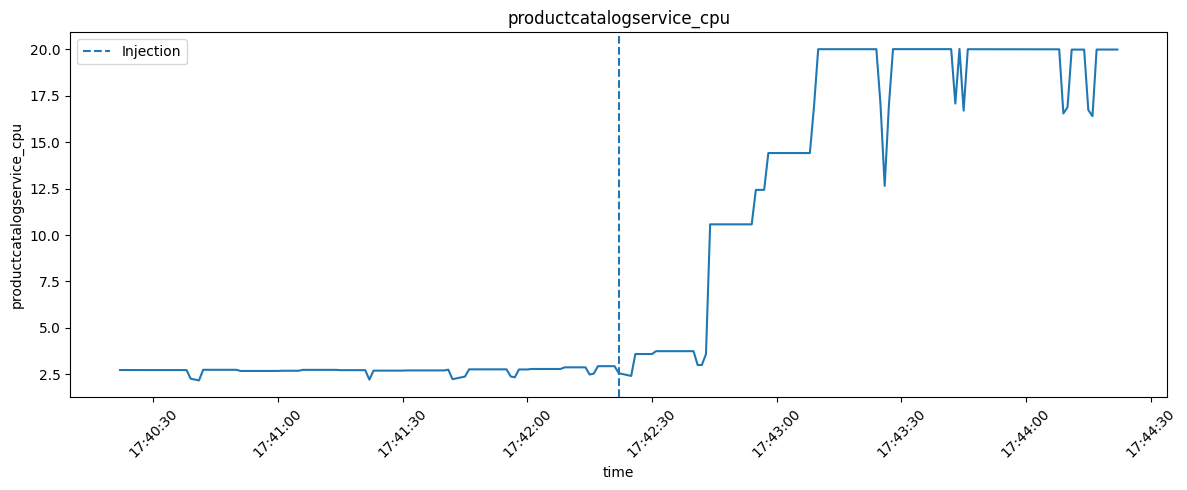

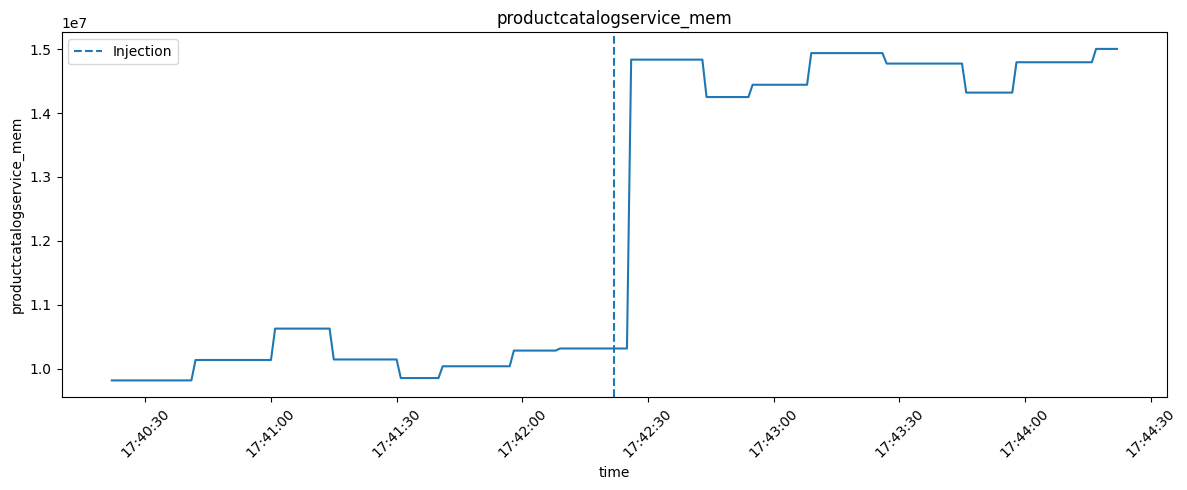

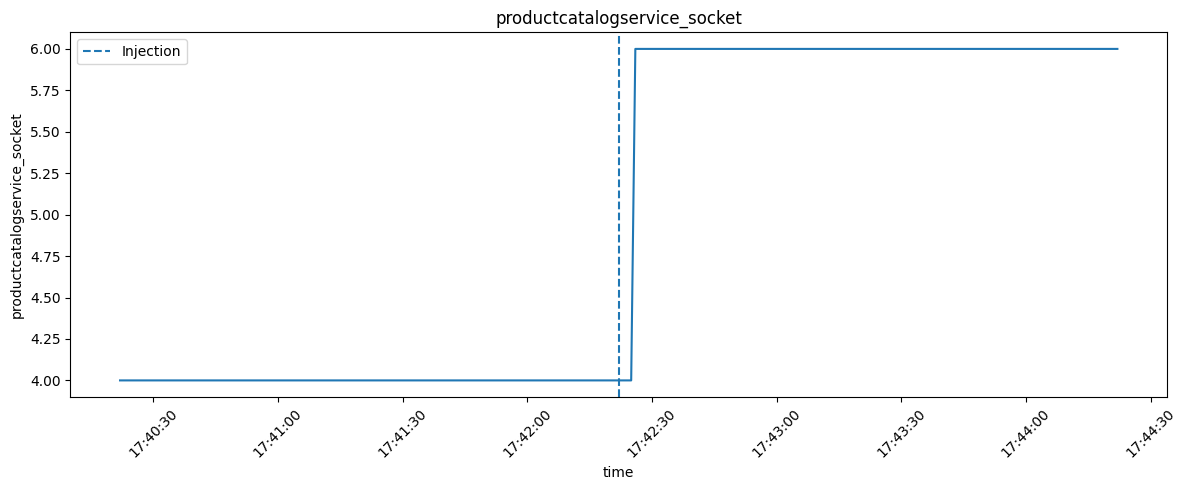

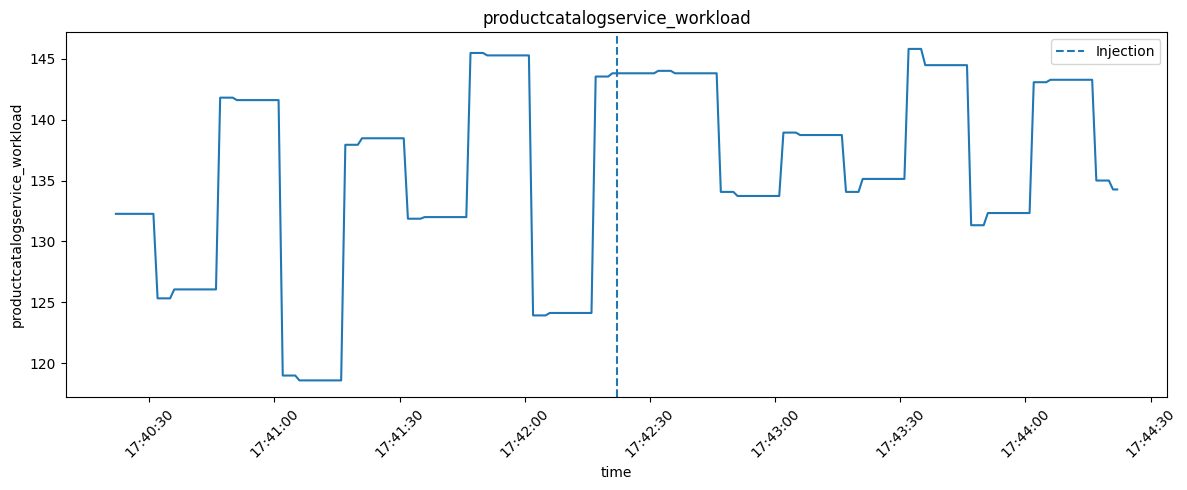

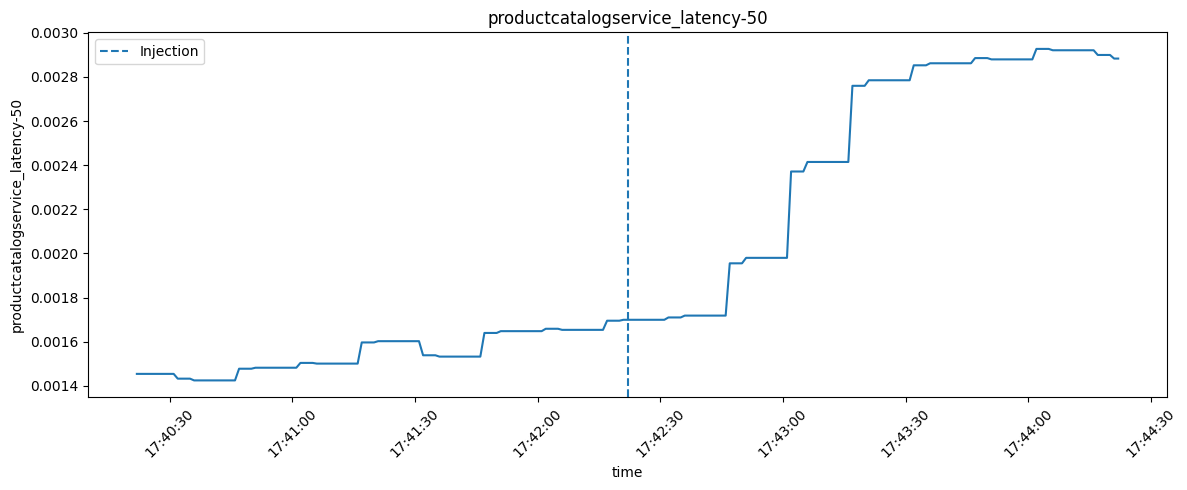

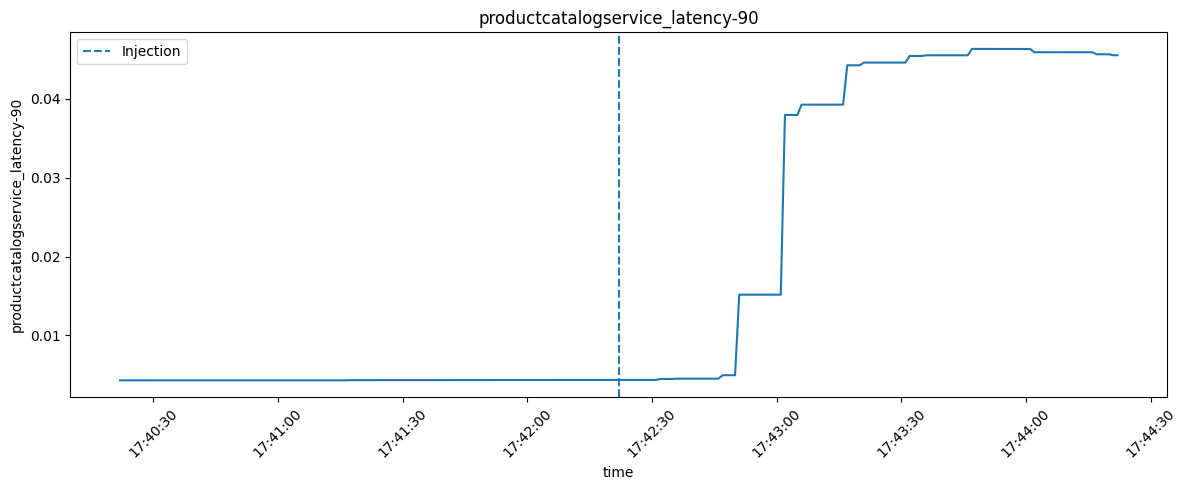

In [21]:
for col in service_cols:

    plt.figure(figsize=(12, 5))

    sns.lineplot( x=window["time"], y=window[col])

    plt.axvline(inject_time,linestyle="--",label="Injection")

    plt.title(col)

    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()

    plt.show()

In [22]:
print(logs.columns.tolist())
print(logs.dtypes)
print(logs.head())

['timestamp', 'container_name', 'message']
timestamp                  Int64
container_name    string[python]
message           string[python]
dtype: object
    timestamp   container_name                          message
0  1705339822         frontend                  request started
1  1705339822         frontend                   view user cart
2  1705339822  currencyservice    conversion request successful
3  1705339822  currencyservice    conversion request successful
4  1705339822  currencyservice  Getting supported currencies...


In [23]:
logs["timestamp_dt"] = pd.to_datetime(
    logs["timestamp"],
    unit="s"
)

In [24]:
print(logs_window.shape)

NameError: name 'logs_window' is not defined

In [25]:
delta = pd.Timedelta(minutes=2)

logs_window = logs[
    (logs["timestamp_dt"] >= inject_time - delta) &
    (logs["timestamp_dt"] <= inject_time + delta)
]

In [29]:
logs_window["container_name"].value_counts()

,count
container_name,
frontend,10159
currencyservice,9143
cartservice,2961
recommendationservice,2158
shippingservice,1730
adservice,1720
checkoutservice,327
paymentservice,218
emailservice,109


In [30]:
print(
    comparison[
        ["before", "fault", "after", "increase_%"]
    ].sort_values("increase_%", ascending=False)
)

                             before         fault         after  increase_%
serviceName                                                                
productcatalogservice      32.58479    120.898589    256.728661  687.878837
recommendationservice    3410.96503   14726.02736  26654.538574  681.436876
frontendservice        44364.747369  44604.833152  50024.646002   12.757649
emailservice             161.853707    173.684729    163.062257    0.746692
checkoutservice        47482.951454  44592.320461   45295.27949   -4.607279
paymentservice           285.543536    257.548387    269.682741   -5.554598
currencyservice         1024.950534   1025.450224    946.035475   -7.699402


In [31]:
print(
    logs_window["message"]
    .value_counts()
    .head(20)
)

message
conversion request successful                                                       6668
request complete                                                                    3047
request started                                                                     3047
Getting supported currencies...                                                     2475
serving product page                                                                1402
[GetQuote] received request                                                          756
[GetQuote] completed request                                                         756
view user cart                                                                       646
received ad request (context_words=[kitchen])                                        448
received ad request (context_words=[accessories])                                    337
adding to cart                                                                       329
env platform 

In [32]:
relevant_logs = logs_window[
    logs_window["container_name"].isin([
        "productcatalogservice",
        "recommendationservice"
    ])
]

print(
    relevant_logs[
        ["timestamp_dt", "container_name", "message"]
    ].sort_values("timestamp_dt").to_string(index=False)
)

       timestamp_dt        container_name                                                                                                       message
2024-01-15 17:40:22 recommendationservice               [Recv ListRecommendations] product_ids=['6E92ZMYYFZ', '66VCHSJNUP', '2ZYFJ3GM2N', 'OLJCESPC7Z']
2024-01-15 17:40:22 recommendationservice [Recv ListRecommendations] product_ids=['1YMWWN1N4O', '2ZYFJ3GM2N', '66VCHSJNUP', 'LS4PSXUNUM', 'OLJCESPC7Z']
2024-01-15 17:40:22 recommendationservice [Recv ListRecommendations] product_ids=['9SIQT8TOJO', 'LS4PSXUNUM', '66VCHSJNUP', '0PUK6V6EV0', 'L9ECAV7KIM']
2024-01-15 17:40:22 recommendationservice [Recv ListRecommendations] product_ids=['1YMWWN1N4O', '6E92ZMYYFZ', '2ZYFJ3GM2N', '66VCHSJNUP', 'LS4PSXUNUM']
2024-01-15 17:40:22 recommendationservice [Recv ListRecommendations] product_ids=['9SIQT8TOJO', '2ZYFJ3GM2N', '0PUK6V6EV0', '66VCHSJNUP', 'OLJCESPC7Z']
2024-01-15 17:40:22 recommendationservice [Recv ListRecommendations] product_ids=['L9ECA